<a href="https://colab.research.google.com/github/adrianacalderon/CaribbeanTraining/blob/main/4_Ensemble_Streamflow_Prediction_(ESP)_brazilian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This tutorial presents an example of seasonal streamflow forecasting using the ***Ensemble Streamflow Prediction (ESP)*** method. In summary, this method assumes that historical sequences of precipitation and other meteorological variables, resampled for the same dates for which the forecast is being produced, are representative of the meteorological conditions that will occur in the future. These sequences are used as input data for a hydrological model with updated initial conditions, i.e., representative of the current state of the basin.

The scripts below are based on the original methodology presented in:

*   *Day, G. N. (1985). Extended streamflow forecasting using NWSRFS. Journal of Water Resources Planning and Management, 111(2), 157-170.*

In this example, we will apply traditional (standard) ESP, in which each past year of the meteorological data series represents a possible future scenario.



---


# **(OPTIONAL) Enable interactive plots with `Matplotlib`**

If we want to enable interactive plots with `Matplotlib`, we can install the `ipympl` package. The lines below are adapted for installation in **Google Colab**, while other platforms for running Python notebooks on a local machine (**Jupyter**, **Visual Studio**) may require some modifications for `ipympl` to work. For more details, see https://matplotlib.org/ipympl/.

There are also other plotting libraries (e.g., `plotly`) that support interactive plots and could be used as an alternative.

In [ ]:
# Install only if interactive graphs (zoom, pan) with matplotlib are desired
!pip install -q ipympl
get_ipython().kernel.do_shutdown(restart=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.9 MB/s eta 0:00:00


{'status': 'ok', 'restart': True}

The previous cell contains a command that **forces a runtime restart**, which ensures the script works properly in Google Colab. You'll get a notification that your session crashed. THIS IS OK! We must **wait for the system to reconnect** before running the cell below and the following scripts in this tutorial. If you want to "run all" at the top, you'll need to comment this cell out.

In [ ]:
# Load matplotlib to use the magic command
from matplotlib import pyplot as plt
# Load widget manager
from google.colab import output
output.enable_custom_widget_manager()

 # Magic command to turn on interactive graphs in matplotlib
%matplotlib ipympl

ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

---

# **Cloning a hydrological model repository**

We will clone the *simple_water_balance* repository from the large-scale hydrology group (HGE/UFRGS), hosted on GitHub. We will do this in order to use a Python script for a simplified hydrological model.

Note: To use the `git clone` command on a platform for running notebooks/Python scripts on a local machine (e.g., **Jupyter**, **Visual Studio Code**), you need to make sure Git is installed on your computer. If it is not, Git can be downloaded from (https://git-scm.com/downloads)

In [ ]:
!git clone https://github.com/HGE-IPH/simple_water_balance.git

Cloning into 'simple_water_balance'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (36/36), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 36 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (36/36), 227.34 KiB | 2.10 MiB/s, done.
Resolving deltas: 100% (12/12), done.



---


# **Import Python Libraries**

Let's import the additional libraries needed to carry out the tutorial. We will also add the path to the hydrological model's Python script so we can import it into our example.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from matplotlib import pyplot as plt

# Importing the hydrological model into 'model'
from simple_water_balance.model import hydrological_model as model

---

# **Create Folders**

Create an output folder in the root directory where we will export the results:

In [ ]:
# Define folder path (e.g., in the current working directory)
folder_output = 'output'

# Create the folder if it doesn't exist
os.makedirs(folder_output, exist_ok=True)

---

# **1. Read the data**





1.1. We will read the .csv files containing daily data for precipitation (P), streamflow (Q), and potential evapotranspiration (PET). Each .csv file must have 2 columns (one with the dates and another with the variable's values), in addition to:

* The title of the date column defined as '*Date*' (without quotes)
* The dates in **YYYY-MM-DD** format

First, we need to define the paths to the .csv files:

In [ ]:
# Set file paths
file_P_path = './simple_water_balance/input_example/P_42395000.csv'
file_PET_path = './simple_water_balance/input_example/PET_42395000.csv'
file_Q_path = './simple_water_balance/input_example/Q_42395000.csv'

1.2. Next, we load the data and exclude implausible values (<0):

In [ ]:
# Load input data:
df_p = pd.read_csv(file_P_path, sep=',', parse_dates=['Date'])
df_pet = pd.read_csv(file_PET_path, sep=',', parse_dates=['Date'])
df_q = pd.read_csv(file_Q_path, sep=',', parse_dates=['Date'])

# Set date column to index
df_p.set_index('Date', inplace=True)
df_q.set_index('Date', inplace=True)
df_pet.set_index('Date', inplace=True)

# Ensure the names of the P and PET columns in csvs
df_p.columns = ['P']
df_pet.columns = ['PET']

# Avoid negative input forcing. Negative streamflows are set to missing data
df_p.mask(df_p < 0.0, 0.0, inplace=True)
df_pet.mask(df_pet < 0.0, 0.0, inplace=True)
df_q.mask(df_q < 0.0, np.nan, inplace=True)

# Convert dataframes into one-dimensional array vectors (Model input format)
p_series = df_p.values.flatten()
pet_series = df_pet.values.flatten()
q_series = df_q.values.flatten()

In [ ]:
q_series.mean()

Additional considerations for the hydrological model to work correctly:

* The P, PET, and Q data series must have a **compatible period** (same start and end dates)
* The **P and PET series must not contain missing data**
* If there is **no Q data** for the entire period covered by the meteorological data, the streamflow .csv file must still contain **all the dates**, and the data corresponding to the missing dates must be left empty.

1.3. Plot daily P, PET, and Q series:

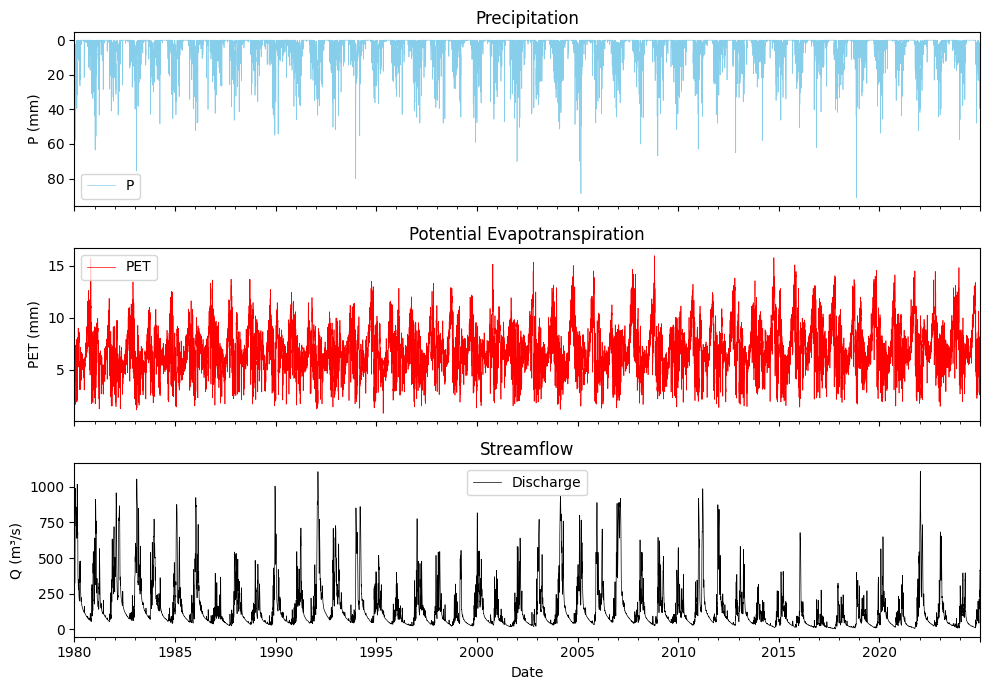

In [ ]:
#@title Plot
# Plot data:
fig, axes = plt.subplots(3,1, sharex=True, figsize=(10, 7))

axes = axes.flatten()

df_p.plot(ax=axes[0], linewidth=0.5, color='skyblue', ylabel='P (mm)', title='Precipitation')
df_pet.plot(ax=axes[1], linewidth=0.5, color='red', ylabel='PET (mm)', title='Potential Evapotranspiration')
df_q.plot(ax=axes[2], linewidth=0.5, color='k', ylabel='Q (m³/s)', title='Streamflow')

# Use inverted y for precipitation
axes[0].invert_yaxis()

plt.tight_layout()
plt.show()

---

# **2. Structure and parameters of the hydrological model**

2.1. For this ESP-based forecasting example, we will use a lumped hydrological model that includes a simplified water balance calculation and streamflow routing:

* The model uses a precipitation (P) and potential evapotranspiration (PET) series as input data;
* The water balance is calculated in a single soil layer, where the generation of surface runoff (Dsup) and subsurface runoff (Dbas) depends on the current water content (W);
* The generation of surface runoff is based on the ARNO model (Todini, 1996), while subsurface runoff occurs through a linear relationship with W;
* Surface runoff routing occurs through the transfer of Dsup across N linear reservoirs in cascade;
* Subsurface runoff routing occurs through a single linear reservoir.

Todini, E. (1996). The ARNO rainfall—runoff model. Journal of hydrology, 175(1-4), 339-382.

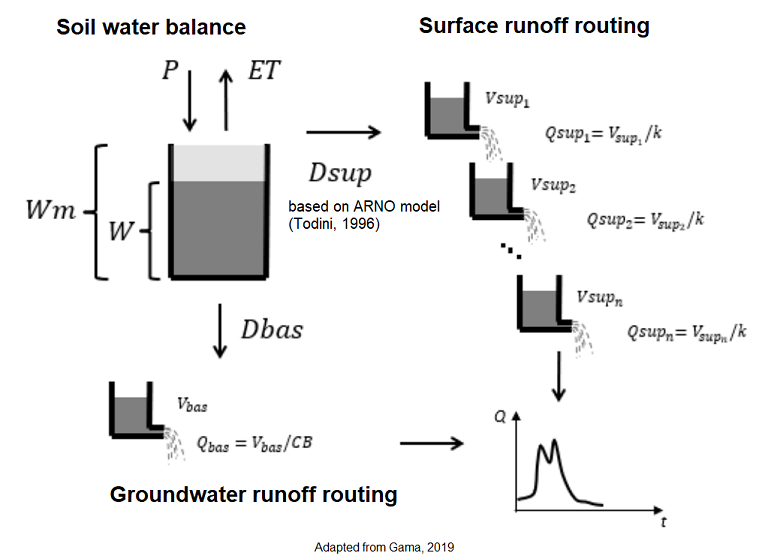

2.2. Now we will define the parameters. The model uses the following parameters, which can be calibrated:
* **Wm**: Maximum soil storage capacity (mm)
* **b**: ARNO model parameter that controls the distribution of saturated areas (-)
* **kbas**: Percolation rate to the aquifer (mm/day)
* **n**: Number of surface reservoirs in cascade
* **k**: Recession coefficient for the surface reservoirs (hours)
* **CB**: Recession coefficient for the subsurface reservoir (days)
* **Ws**: Threshold fraction of soil moisture at which ET reduction begins (-)

In [ ]:
# Calibrated parameters
Wm = 800.0   # Suggested range: 50 - 1000
b = 0.8      # Suggested range: 0.01 - 1.6
kbas = 1.5   # Suggested range: 0.01 - 10
n = 3        # Suggested range: 1-3
k = 72.0     # (hours), must be higher than model time step (> 24 h)
CB = 100.0   # (days), must be higher than model time step (> 1 d)
Ws = 0.5     # Suggested range: 0.5 - 1.0 (must be <= 1.0)

2.3. In addition to the calibration parameters, the calculation time step (in seconds) and the catchment area (km²) must also be defined:

In [ ]:
# Model setup
time_step = 86400      # (s) 86400 seconds = 1 day
catchment_area = 13000 # (km²)

---

# **3. Run the hydrological simulation**

3.1. Before applying the hydrological model, we will generate arbitrary initial conditions by calling the `generate_ic` function, available on the `model` object:

In [ ]:
# Generates initial conditions, using 5 L/s.km² as specific average streamflow
initial_state = model.generate_ic(q_specific=5.0, n_casc_reservoirs=n,
                            Wm=Wm, CB=CB, area=catchment_area)

# Defining names for state variables
states_name = ['W','Vbas']
states_name.extend([f'Vsup{i}' for i in range(1,n+1)]) # depends on the number of surface reservoirs
states_name.append('Q sim')

print('initial conditions:')
display(states_name)
display(initial_state)

initial conditions:


['W', 'Vbas', 'Vsup1', 'Vsup2', 'Vsup3', 'Q sim']

array([400. , 561.6,   0. ,   0. ,   0. ,  65. ])

3.2. We call the `run_model` function, available on the `model` object, to apply the hydrological model at each time step. For this, the following input variables are used:

* `initial_state`: the vector with the initial conditions
* `p_series`: the precipitation data vector
* `pet_series`: the potential evapotranspiration data vector
* `calib_parameters`: dictionary containing the calibrated parameter values
* `model_setup`: dictionary containing the model configuration values

In [ ]:
# Run model with user-defined parameters and model setup
results = model.run_model(initial_state, p_series, pet_series,
                    calib_parameters={'Wm': Wm, 'b': b, 'kbas': kbas, 'n': n, 'k': k, 'CB': CB, 'Ws': Ws},
                    model_setup={'dt':time_step, 'area': catchment_area})

# Converting results to dataframe
df_states = pd.DataFrame(results, index=df_p.index, columns=states_name)

# Checking the first results
display(df_states)

,W,Vbas,Vsup1,Vsup2,Vsup3,Q sim
Date,,,,,,
1980-01-01,402.616718,556.726500,3.910766,1.723334,0.714360,861.917509
1980-01-02,409.234517,551.906592,3.363328,2.269999,1.232906,892.545393
1980-01-03,406.002977,547.147168,2.335892,2.291963,1.585925,924.322890
1980-01-04,398.171212,542.429339,1.574839,2.052922,1.741591,943.710741
1980-01-05,390.281420,537.744151,1.049893,1.718579,1.733920,948.301011
...,...,...,...,...,...,...
2024-12-27,336.976134,27.531619,8.317763,6.903207,5.497821,402.587860
2024-12-28,346.872232,27.881814,8.286622,7.364345,6.119995,455.984746
2024-12-29,357.064545,28.246878,8.065462,7.598051,6.612681,503.346717


3.3. We can calculate performance metrics for the simulated streamflow, which allows us to refine the calibration parameters if necessary. We will use some traditional efficiency metrics such as Nash-Sutcliffe $(NS)$, Nash-Sutcliffe of the log-transformed streamflow $(NS_{log})$, and bias $(bias)$:

\begin{align}
 NSE = 1-\frac{\sum_{i=1}^{N} (qs_{i}-qo_{i})^2}{\sum_{i=1}^{N} (qs_{i}-\overline{qo})^2}
\end{align}

\begin{align}
 NSE_{log} = 1-\frac{\sum_{i=1}^{N} (log(qs_{i})-log(qo_{i}))^2}{\sum_{i=1}^{N} (log(qs_{i})-log(\overline{qo}))^2}
\end{align}

\begin{align}
 Bias = \frac{\sum_{i=1}^{N} (qs_{i})-\sum_{i=1}^{N} (qo_{i})}{\sum_{i=1}^{N} (qo_{i})}
\end{align}

Where:

* $ qs_{i} $ and $ qo_{i} $ are the simulated and observed streamflow for time step $i$;
* $ \overline{qo_i} $ is the average observed streamflow;
* $ N $ is the total number of time steps.

When calculating the model's performance metrics, we **will not include the first year** of the simulation, in order to reduce the effect of the initial conditions.

In [ ]:
# Converting from dataFrame to array
q_sim = df_states['Q sim'].values.flatten()

# Select dates with valid observed data to compute metrics
valid = np.isnan(q_series) == False

# Excluding first year from metric computations
valid[0:364] = False

# Nash-Sutcliffe
nse = 1 - np.sum((q_sim[valid] - q_series[valid])**2.0) / np.sum((q_series[valid] - np.mean(q_series[valid]))**2.0)

# Nash-Sutcliffe of log flows
nse_log = 1 - np.sum((np.log(q_sim[valid]) - np.log(q_series[valid]))**2.0) / \
                np.sum((np.log(q_series[valid]) - np.mean(np.log(q_series[valid])))**2.0)

# Bias
bias = 100 * (np.sum(q_sim[valid]) - np.sum(q_series[valid])) / np.sum(q_series[valid])

3.4. Plotting the graph with the observed and simulated streamflow series, along with the performance metrics:

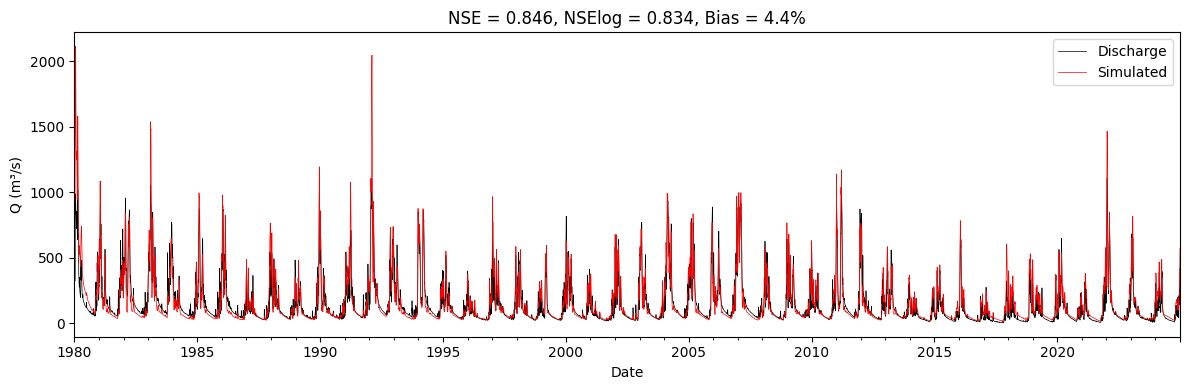

In [ ]:
#@title Plot
# Generating strings for rounded metrics
str_nse = str(np.round(nse,3))
str_nse_log = str(np.round(nse_log,3))
str_bias = str(np.round(bias,1))

# Plotting the figure
fig, ax = plt.subplots(figsize=(12, 4))

df_q.plot(ax=ax, color='k', linewidth=0.5)
df_states['Q sim'].plot(ax=ax, color='r', linewidth=0.5, label='Simulated')
ax.set_ylabel('Q (m³/s)')
ax.set_title(f'NSE = {str_nse}, NSElog = {str_nse_log}, Bias = {str_bias}%')

plt.legend()
plt.tight_layout()
plt.show()

---
# **4. Resampling past meteorological data sequences**

4.1. In this step, we will resample the P and PET sequences from our historical data to use them as future climate variability. First, we need to define the **forecast start date** (`fcst_start_date`) and its **range** (`fcst_range`):

In [ ]:
# Set forecast start date (YYYY-MM-DD) and range (days)
fcst_start_date = '2025-01-01'
fcst_range = 180 # days

# Converting date from string to datetime
dt_fcst = datetime.strptime(fcst_start_date, '%Y-%m-%d')

4.2. We must search the available historical record for all dates whose calendar day and month match the start date of the forecast.

In [ ]:
# Get year, month, and day of the forecast start date
resampling_start_month = dt_fcst.month
resampling_start_year = dt_fcst.year
resampling_start_day = dt_fcst.day

# Find dates of all calendar months and days = forecast date,
# ensuring they do not include the same year of the forecast
start_indices = df_p.index[(df_p.index.month == resampling_start_month) &
                           (df_p.index.day == resampling_start_day) &
                            (df_p.index.year != resampling_start_year)]

print(start_indices)

DatetimeIndex(['1980-01-01', '1981-01-01', '1982-01-01', '1983-01-01',
               '1984-01-01', '1985-01-01', '1986-01-01', '1987-01-01',
               '1988-01-01', '1989-01-01', '1990-01-01', '1991-01-01',
               '1992-01-01', '1993-01-01', '1994-01-01', '1995-01-01',
               '1996-01-01', '1997-01-01', '1998-01-01', '1999-01-01',
               '2000-01-01', '2001-01-01', '2002-01-01', '2003-01-01',
               '2004-01-01', '2005-01-01', '2006-01-01', '2007-01-01',
               '2008-01-01', '2009-01-01', '2010-01-01', '2011-01-01',
               '2012-01-01', '2013-01-01', '2014-01-01', '2015-01-01',
               '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01',
               '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01',
               '2024-01-01'],
              dtype='datetime64[ns]', name='Date', freq=None)


4.3. We can build a table containing sequences of length '*fcst_range*' that start on the previously identified dates.

In [ ]:
# Get the resampled dates corresponding to forecast calendar dates
resampling_indices = {
    idx.year: pd.date_range(start=idx, periods=fcst_range, freq='D')
    for idx in start_indices}

# Generate sequence of (future) forecast dates
fcst_dates = pd.date_range(start=dt_fcst, periods=fcst_range, freq='D')

# Generate dataframe
df_resampled_dates = pd.DataFrame(resampling_indices, index=fcst_dates)
display(df_resampled_dates)

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2025-01-01,1980-01-01,1981-01-01,1982-01-01,1983-01-01,1984-01-01,1985-01-01,1986-01-01,1987-01-01,1988-01-01,1989-01-01,...,2015-01-01,2016-01-01,2017-01-01,2018-01-01,2019-01-01,2020-01-01,2021-01-01,2022-01-01,2023-01-01,2024-01-01
2025-01-02,1980-01-02,1981-01-02,1982-01-02,1983-01-02,1984-01-02,1985-01-02,1986-01-02,1987-01-02,1988-01-02,1989-01-02,...,2015-01-02,2016-01-02,2017-01-02,2018-01-02,2019-01-02,2020-01-02,2021-01-02,2022-01-02,2023-01-02,2024-01-02
2025-01-03,1980-01-03,1981-01-03,1982-01-03,1983-01-03,1984-01-03,1985-01-03,1986-01-03,1987-01-03,1988-01-03,1989-01-03,...,2015-01-03,2016-01-03,2017-01-03,2018-01-03,2019-01-03,2020-01-03,2021-01-03,2022-01-03,2023-01-03,2024-01-03
2025-01-04,1980-01-04,1981-01-04,1982-01-04,1983-01-04,1984-01-04,1985-01-04,1986-01-04,1987-01-04,1988-01-04,1989-01-04,...,2015-01-04,2016-01-04,2017-01-04,2018-01-04,2019-01-04,2020-01-04,2021-01-04,2022-01-04,2023-01-04,2024-01-04
2025-01-05,1980-01-05,1981-01-05,1982-01-05,1983-01-05,1984-01-05,1985-01-05,1986-01-05,1987-01-05,1988-01-05,1989-01-05,...,2015-01-05,2016-01-05,2017-01-05,2018-01-05,2019-01-05,2020-01-05,2021-01-05,2022-01-05,2023-01-05,2024-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-25,1980-06-24,1981-06-25,1982-06-25,1983-06-25,1984-06-24,1985-06-25,1986-06-25,1987-06-25,1988-06-24,1989-06-25,...,2015-06-25,2016-06-24,2017-06-25,2018-06-25,2019-06-25,2020-06-24,2021-06-25,2022-06-25,2023-06-25,2024-06-24
2025-06-26,1980-06-25,1981-06-26,1982-06-26,1983-06-26,1984-06-25,1985-06-26,1986-06-26,1987-06-26,1988-06-25,1989-06-26,...,2015-06-26,2016-06-25,2017-06-26,2018-06-26,2019-06-26,2020-06-25,2021-06-26,2022-06-26,2023-06-26,2024-06-25
2025-06-27,1980-06-26,1981-06-27,1982-06-27,1983-06-27,1984-06-26,1985-06-27,1986-06-27,1987-06-27,1988-06-26,1989-06-27,...,2015-06-27,2016-06-26,2017-06-27,2018-06-27,2019-06-27,2020-06-26,2021-06-27,2022-06-27,2023-06-27,2024-06-26
2025-06-28,1980-06-27,1981-06-28,1982-06-28,1983-06-28,1984-06-27,1985-06-28,1986-06-28,1987-06-28,1988-06-27,1989-06-28,...,2015-06-28,2016-06-27,2017-06-28,2018-06-28,2019-06-28,2020-06-27,2021-06-28,2022-06-28,2023-06-28,2024-06-27


4.4. We map the values of our daily P and PET time series for the dates previously identified in each sequence.

In [ ]:
# Mapping data from time series to their corresponding dates in table
# If dates are not found, fill with NaN values
df_p_resampled = df_resampled_dates.map(lambda t: df_p.loc[t, 'P'] if t in df_p.index else np.nan)
df_pet_resampled = df_resampled_dates.map(lambda t: df_pet.loc[t, 'PET'] if t in df_pet.index else np.nan)

print('Resampled P series:')
display(df_p_resampled)

Resampled P series:


,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2025-01-01,10.56,25.75,8.37,9.30,5.72,5.48,8.90,3.15,16.97,3.19,...,1.22,0.00,0.00,5.43,17.89,2.73,0.00,27.27,20.58,18.39
2025-01-02,14.64,21.87,19.42,14.92,6.29,3.55,13.33,13.32,23.87,3.33,...,0.00,4.80,0.00,7.25,4.84,24.23,5.81,17.69,9.33,14.91
2025-01-03,4.14,43.64,21.85,20.70,0.24,5.97,12.50,5.21,4.28,5.73,...,2.55,3.69,0.00,6.68,4.22,17.67,2.58,24.13,13.44,25.27
2025-01-04,0.52,4.02,16.18,8.49,0.22,13.30,17.63,0.42,19.89,26.59,...,8.63,10.79,0.93,19.05,0.37,20.82,7.44,22.88,5.36,45.87
2025-01-05,0.10,1.00,12.58,20.97,4.49,28.41,13.58,0.00,6.56,13.44,...,3.31,8.37,11.22,33.12,0.36,1.96,1.49,16.55,20.24,23.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-25,0.36,0.00,0.00,0.00,0.00,0.00,0.00,0.11,0.00,0.38,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2025-06-26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,5.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2025-06-27,0.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2025-06-28,21.58,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


4.5. Finally, we must exclude any resampled sequence that, for any reason, contains invalid data (NaN values).

In [ ]:
# Check if there are missing values
fcst_p_missing = np.isnan(df_p_resampled).sum(axis=0)
fcst_pet_missing = np.isnan(df_pet_resampled).sum(axis=0)

# If there are years with missing data either in forecast p or pet, drop them
missing_years = fcst_p_missing + fcst_pet_missing
if missing_years.sum() > 0:
    idx = missing_years[missing_years > 0].index
    df_p_resampled = df_p_resampled.drop(idx, axis=1)
    df_pet_resampled = df_pet_resampled.drop(idx, axis=1)


---

# **5. Generate ESP Forecast**

5.1. Before running the model, we must select the catchment initial conditions (ICs) that are up to date, i.e., those corresponding to the date for which we want to generate the forecast. To do this, we can select the ICs from the previous day (for the end of the time step).

In [ ]:
# Identify the day before the forecast start date
dt_ic = dt_fcst + pd.tseries.offsets.DateOffset(days=-1)

# Get the initial condition for the day before the forecast start date
df_ic_fcst = df_states[df_states.index==dt_ic]

display(df_ic_fcst)

,W,Vbas,Vsup1,Vsup2,Vsup3,Q sim
Date,,,,,,
2024-12-31,372.631502,29.01705,8.369827,7.85531,7.02689,572.744289


5.2. Using the updated initial conditions, we run the model with each of the historical precipitation sequences previously selected, generating the ESP forecast (with daily streamflows).

In [ ]:
# Converting ic to array vector
ic_fcst = df_ic_fcst.values.flatten()
# Initializing Q forecast variable
q_fcst = np.zeros((fcst_range, df_p_resampled.shape[1]))

# Run model for each ensemble member (year)
for m, col in enumerate(df_p_resampled.columns):

    results = model.run_model(ic_fcst, df_p_resampled[col].values, df_pet_resampled[col].values,
                           calib_parameters={'Wm': Wm, 'b': b, 'kbas': kbas, 'n': n, 'k': k, 'CB': CB, 'Ws': Ws},
                           model_setup={'dt':time_step, 'area': catchment_area})

    # Store streamflow for each ensemble member
    q_fcst[:,m] = results[:,-1]

# Convert ensemble forecast from array to DataFrame
df_fcst = pd.DataFrame(q_fcst, index=df_p_resampled.index, columns=df_p_resampled.columns)

display(df_fcst)

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
2025-01-01,589.605293,613.043855,622.945973,617.601520,595.713409,561.667359,525.892535,485.344443,461.052007,436.794240,...,742.641442,675.267054,593.775829,516.301476,467.414341,427.728493,386.872049,381.782911,404.721883,442.169797
2025-01-02,598.059909,644.155503,632.682730,609.232618,563.259739,519.097635,500.101339,456.271909,467.172881,409.328093,...,675.848077,600.712064,509.470569,453.059337,431.395927,420.511804,351.898288,402.581027,430.490275,481.321386
2025-01-03,587.361449,715.385084,649.896551,610.810337,517.190551,475.450783,484.565028,429.963744,471.332652,382.009120,...,598.190356,527.556996,428.944650,404.314944,399.991851,435.788402,319.715037,448.731359,455.077297,531.908158
2025-01-04,554.575982,761.933108,666.813425,606.513825,461.985483,444.907973,485.074601,397.763434,487.420666,385.262989,...,528.065896,470.171995,357.492846,385.362292,365.620290,469.562253,296.300210,511.303718,465.542838,627.249409
2025-01-05,505.202663,764.338189,675.619640,612.113758,408.785719,450.949336,493.811790,359.283869,496.508047,402.956737,...,464.801544,427.893035,309.474460,415.206505,328.063811,487.430000,274.356740,571.933284,482.722040,729.024449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-25,75.913736,67.688838,80.701352,94.507686,46.809147,67.911608,53.438004,53.211161,62.469887,50.777458,...,66.388435,52.541884,43.995208,55.264380,57.848024,70.223700,47.705733,55.458841,54.485659,64.048589
2025-06-26,75.867112,66.697795,80.353695,93.867802,46.545999,67.524385,53.105115,53.007393,62.160712,51.618773,...,66.104568,52.146596,43.712689,54.951445,57.598384,69.879423,47.352881,55.072462,53.796783,63.646534
2025-06-27,75.980934,65.875932,80.008267,93.257559,46.282026,67.136681,52.770526,52.753890,61.875580,52.410996,...,65.823158,51.759356,43.420073,54.640971,57.350181,69.533403,47.008320,54.686848,53.141879,63.243911
2025-06-28,85.067920,65.186284,79.662812,92.674350,46.017256,66.748812,52.434505,52.455261,61.575849,52.770491,...,65.541756,51.378415,43.120096,54.332357,57.101191,69.186016,46.670737,54.302231,52.530849,62.841068


5.3. Aggregating the daily streamflow forecast series into monthly averages:

In [ ]:
# Resampling forecast from daily to monthly time step
df_forecast_month = df_fcst.resample('MS').mean()
df_forecast_month.columns = [f'M{i}' for i in range(1, df_fcst.columns.size+1)]
df_forecast_month.index.name = 'Date'

5.4. Plotting the final forecast chart.

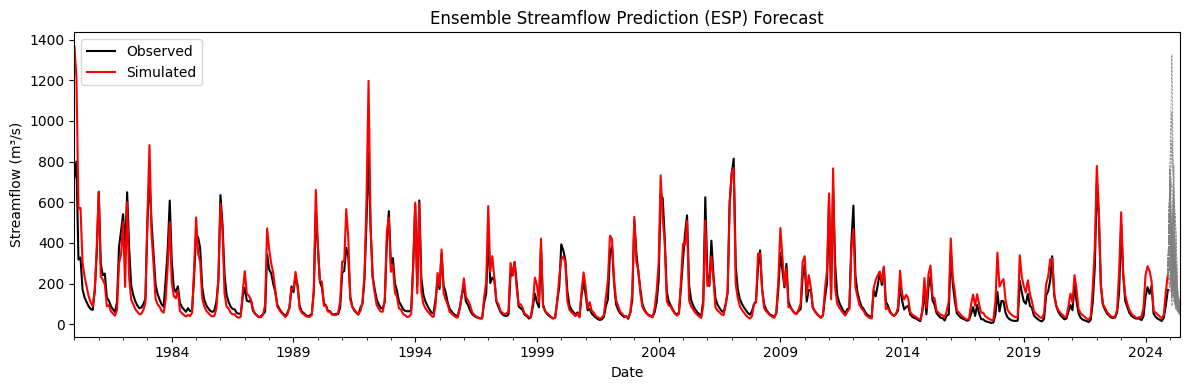

In [ ]:
#@title Plot
# Resample daily observed and simulated to monthly time step
df_month = df_q.resample('MS').mean()
df_month_sim = df_states['Q sim'].resample('MS').mean()

# This part is only for visualization purposes
# Creating continuity between simulation and forecast traces
start_dt = df_forecast_month.index[0] + pd.tseries.offsets.DateOffset(months=-1)
df_last_sim = pd.DataFrame(df_month_sim[start_dt].repeat(df_forecast_month.shape[1])).T
df_last_sim['Date'] = start_dt
df_last_sim.set_index('Date', inplace=True)
df_last_sim.columns = [f'M{i}' for i in range(1, df_fcst.columns.size+1)]
df_forecast_plot = pd.concat([df_last_sim, df_forecast_month], axis=0)

# Plot on screen
fig, ax = plt.subplots(figsize=(12, 4))

df_month.plot(ax=ax, color='k')
df_month_sim.plot(ax=ax, color='r')
df_forecast_plot.plot(ax=ax, color='gray', linestyle='--', linewidth=0.5, legend=False)
ax.set_ylabel('Streamflow (m³/s)')
ax.set_title('Ensemble Streamflow Prediction (ESP) Forecast')

plt.legend(['Observed', 'Simulated'])
plt.tight_layout()
plt.show()

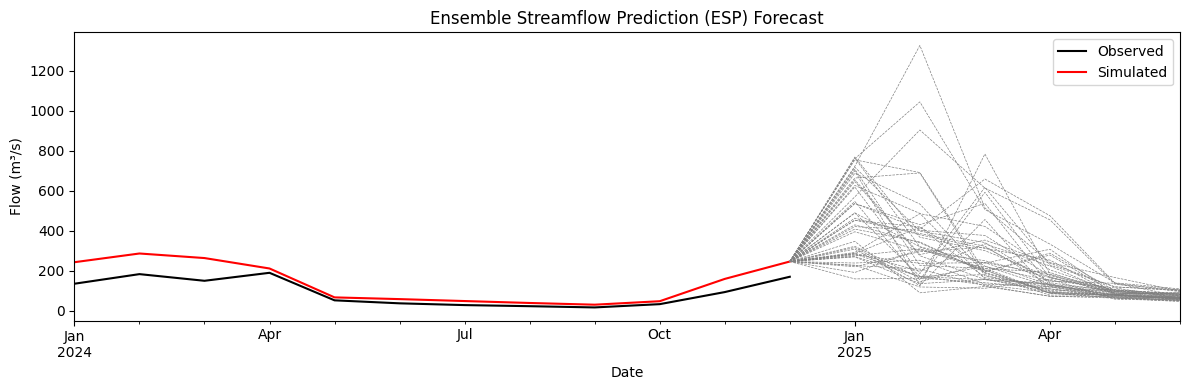

In [ ]:
#@title Plot
# Resample daily observed and simulated to monthly time step
df_month = df_q.resample('MS').mean()
df_month_sim = df_states['Q sim'].resample('MS').mean()

# This part is only for visualization purposes
# Creating continuity between simulation and forecast traces
start_dt = df_forecast_month.index[0] + pd.tseries.offsets.DateOffset(months=-1)
df_last_sim = pd.DataFrame(df_month_sim[start_dt].repeat(df_forecast_month.shape[1])).T
df_last_sim['Date'] = start_dt
df_last_sim.set_index('Date', inplace=True)
df_last_sim.columns = [f'M{i}' for i in range(1, df_fcst.columns.size+1)]
df_forecast_plot = pd.concat([df_last_sim, df_forecast_month], axis=0)

df_month = df_month[df_month.index>='01-01-2024']
df_month_sim = df_month_sim[df_month_sim.index>='01-01-2024']

# Plot on screen
fig, ax = plt.subplots(figsize=(12, 4))

df_month.plot(ax=ax, color='k')
df_month_sim.plot(ax=ax, color='r')
df_forecast_plot.plot(ax=ax, color='gray', linestyle='--', linewidth=0.5, legend=False)
ax.set_ylabel('Flow (m³/s)')
ax.set_title('Ensemble Streamflow Prediction (ESP) Forecast')

plt.legend(['Observed', 'Simulated'])
plt.tight_layout()
plt.show()

---

# **6. Export the generated forecast**

Finally, we can export our streamflow forecasts to the specified output folder. The resulting file will contain multiple columns corresponding to the ESP ensemble members (M1, M2, M3, ..., etc.).

In [ ]:
# Save to CSV
file_name = Path(file_Q_path).stem
df_forecast_month.to_csv(f'{folder_output}/ESP_{file_name}_{fcst_start_date}.csv', float_format='%.2f')